 # Import Libraries

In [136]:
import pandas as pd
import numpy as np
import os
os.chdir("..")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

Load Dataset

In [137]:
df = pd.read_csv(r"C:\Users\ayush\OneDrive\Desktop\Financial Fraud Detection\Dataset\creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Exploratory Data Analysis (EDA)

In [138]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [139]:
df.shape

(284807, 31)

In [140]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [141]:
df.describe()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [142]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [143]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

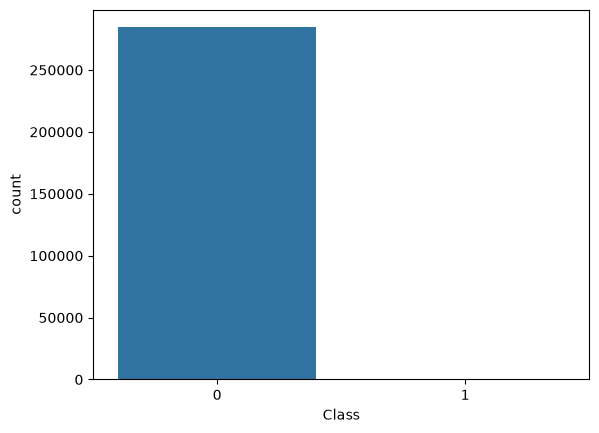

In [144]:
sns.countplot(x='Class', data=df)
plt.show()


Separate Features and Target

In [145]:
x = df.drop("Class", axis=1)
y = df["Class"]

Split the Dataset

In [146]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

Apply SMOTE

In [147]:
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train,y_train)

In [148]:
y_train.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

Feature Scaling

In [149]:
scaler = StandardScaler()

In [150]:
x_train = scaler.fit_transform(x_train)


In [151]:
x_test = scaler.transform(x_test)

Build the ANN

In [152]:
model = Sequential()

Input + first hidden layer

In [153]:
model.add(Dense(64, activation="relu", input_shape=(x_train.shape[1],)))
model.add(Dropout(0.3)) 

c:\Users\ayush\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Second hidden layer

In [154]:
model.add(Dense(32, activation="relu"))
model.add(Dropout(0.2))

Third hidden layer

In [155]:
model.add(Dense(16, activation="relu"))

Output layer

In [156]:
model.add(Dense(1, activation="sigmoid"))

Compile the Model

In [157]:
import tensorflow as tf

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

Train the ANN

In [159]:
history = model.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.9851 - loss: 0.0434 - precision: 0.9843 - recall: 0.9759 - val_accuracy: 0.9962 - val_loss: 0.0115 - val_precision: 1.0000 - val_recall: 0.9962
Epoch 2/30
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step - accuracy: 0.9948 - loss: 0.0164 - precision: 0.9917 - recall: 0.9943 - val_accuracy: 0.9976 - val_loss: 0.0104 - val_precision: 1.0000 - val_recall: 0.9976
Epoch 3/30
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step - accuracy: 0.9962 - loss: 0.0123 - precision: 0.9938 - recall: 0.9961 - val_accuracy: 0.9917 - val_loss: 0.0183 - val_precision: 1.0000 - val_recall: 0.9917
Epoch 4/30
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - accuracy: 0.9968 - loss: 0.0105 - precision: 0.9947 - recall: 0.9968 - val_accuracy: 0.9999 - val_loss: 0.0015 - val_precision: 1.0000 - val_recall: 0.9999
Epoch 5/30
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.9972 - loss: 0.0095 - precision: 0.9956 - recall: 0.9971 - val_accura

Plot Learning Curves

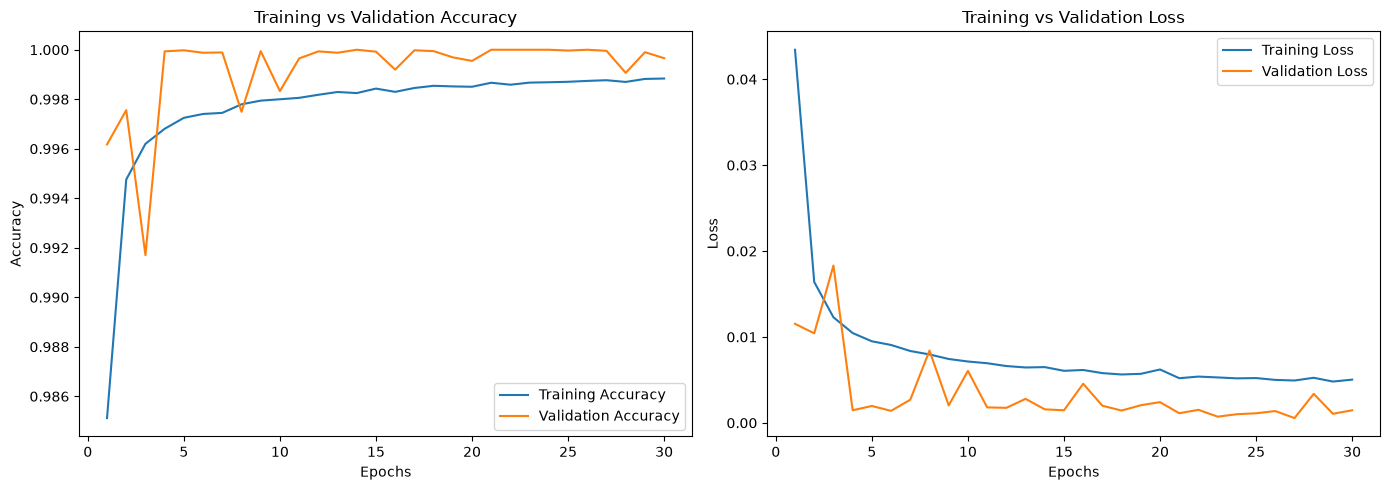

In [160]:
acc_key = "accuracy" if "accuracy" in history.history else "acc"
val_acc_key = "val_accuracy" if "val_accuracy" in history.history else "val_acc"
loss_key = "loss"
val_loss_key = "val_loss"
epochs = range(1, len(history.history[loss_key]) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history.history[acc_key], label="Training Accuracy")
plt.plot(epochs, history.history[val_acc_key], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history.history[loss_key], label="Training Loss")
plt.plot(epochs, history.history[val_loss_key], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

Test the Model

In [161]:
results = model.evaluate(x_test, y_test)

for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9989 - loss: 0.0130 - precision: 0.6439 - recall: 0.8673
loss: 0.0130
compile_metrics: 0.9989


Predict Fraud

In [162]:
probabilities = model.predict(x_test)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 924us/step


In [163]:
predictions = (probabilities >= 0.5).astype(int)

Evaluate Performance

In [164]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [165]:
y_pred_prob = model.predict(x_test)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 689us/step


In [166]:
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.9671


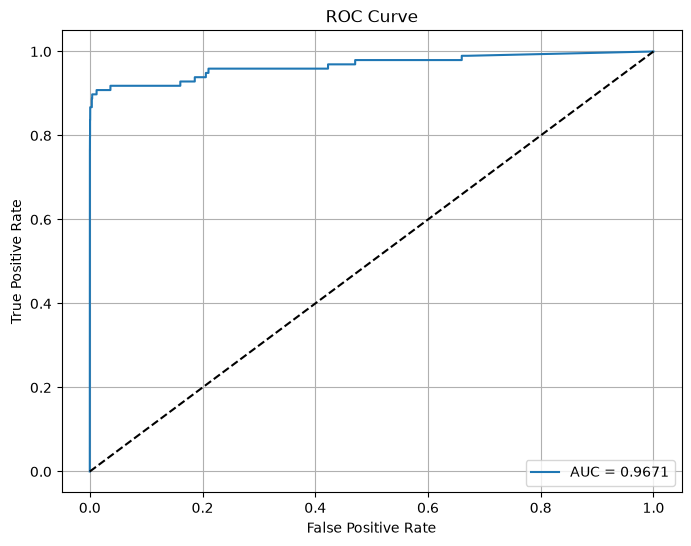

In [167]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], 'k--')   # Random Classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [168]:
y_pred = (y_pred_prob > 0.35).astype(int)

In [169]:
y_pred = y_pred.flatten()

In [170]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[56811    53]
 [   13    85]]


In [171]:
print("True Positives :", cm[1][1])
print("False Positives:", cm[0][1])
print("True Negatives :", cm[0][0])
print("False Negatives:", cm[1][0])

True Positives : 85
False Positives: 53
True Negatives : 56811
False Negatives: 13


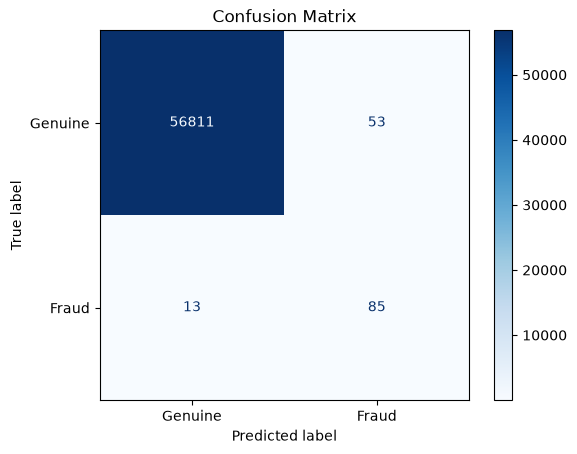

In [172]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Genuine", "Fraud"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [173]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.62      0.87      0.72        98

    accuracy                           1.00     56962
   macro avg       0.81      0.93      0.86     56962
weighted avg       1.00      1.00      1.00     56962



Save the Model

In [174]:
model.save(r"C:\Users\ayush\OneDrive\Desktop\Financial Fraud Detection\models\fraud_ann.keras")